# 3. Pipeline Statistics & Visualization

## Purpose

This notebook loads `pipeline_data/classified_results.csv` — produced by the consumer/classifier —
and generates the following visualizations:

1. **Normal vs Anomalous** — pie chart of overall traffic split
2. **Attack Type Distribution** — bar chart of detected attack types
3. **MITRE ATT&CK Tactics** — frequency of tactics triggered
4. **MITRE ATT&CK Techniques** — frequency of technique IDs
5. **Confidence Score Distribution** — histogram of ML confidence
6. **Events Over Time** — stacked bar chart (attack types by time bucket)
7. **Summary table** — totals printed to console

**Run this notebook after the producer + consumer have been running for a while.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

CSV_PATH = '/home/jovyan/work/pipeline_data/classified_results.csv'

if not os.path.exists(CSV_PATH):
    print(f'ERROR: {CSV_PATH} not found.')
    print('Run notebook 1 (producer) and notebook 2 (consumer) first, then re-run this cell.')
else:
    df = pd.read_csv(CSV_PATH)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    print(f'Loaded {len(df)} classified events.')
    print(df[['ml_label','attack_type','mitre_id','mitre_tactic','confidence']].head(8).to_string())

Loaded 298 classified events.
    ml_label          attack_type   mitre_id mitre_tactic  confidence
0     normal                  NaN        NaN          NaN      0.9998
1     normal                  NaN        NaN          NaN      0.9950
2  anomalous    command_injection      T1059    Execution      1.0000
3  anomalous  parameter_tampering  T1565.001       Impact      1.0000
4  anomalous  parameter_tampering  T1565.001       Impact      1.0000
5     normal                  NaN        NaN          NaN      1.0000
6     normal                  NaN        NaN          NaN      1.0000
7     normal                  NaN        NaN          NaN      1.0000


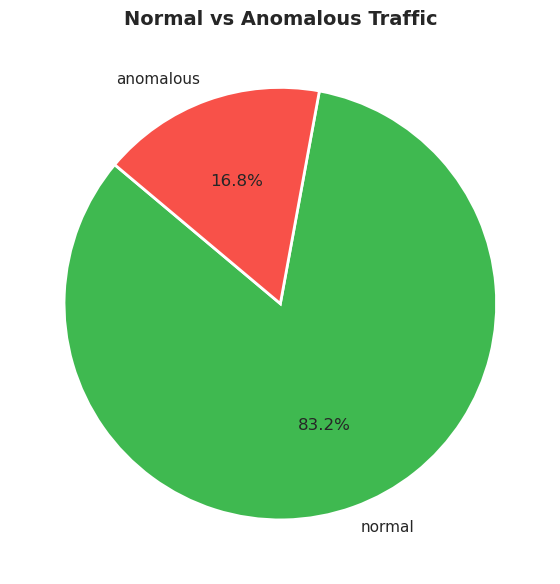

ml_label
normal       248
anomalous     50


In [2]:
# ── 1. Normal vs Anomalous pie chart ──────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
COLORS = {'normal': '#3fb950', 'anomalous': '#f85149'}

label_counts = df['ml_label'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=[COLORS.get(l, '#8b949e') for l in label_counts.index],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
ax.set_title('Normal vs Anomalous Traffic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(label_counts.to_string())

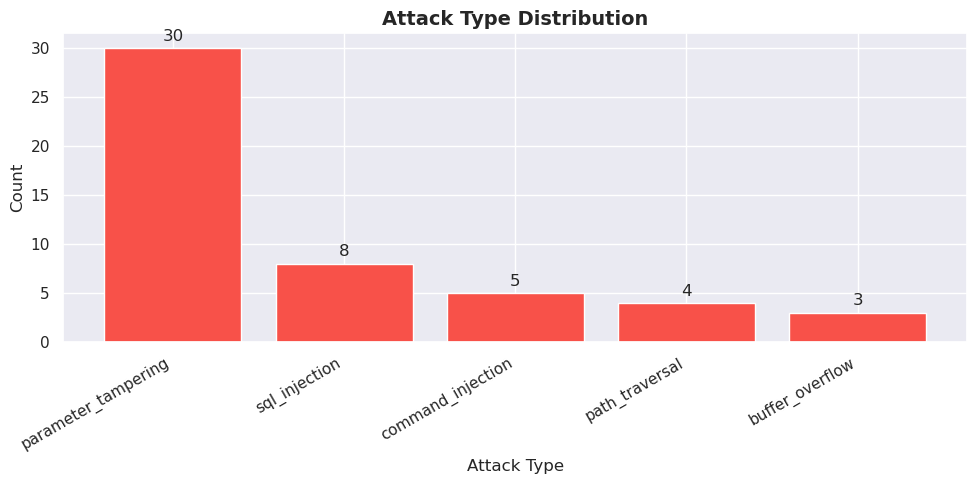

In [3]:
# ── 2. Attack Type Distribution ────────────────────────────────────────────
attacks_df = df[df['ml_label'] == 'anomalous'].copy()
attack_counts = attacks_df['attack_type'].replace('', 'unknown').value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(attack_counts.index, attack_counts.values, color='#f85149', edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('Attack Type Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Type')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

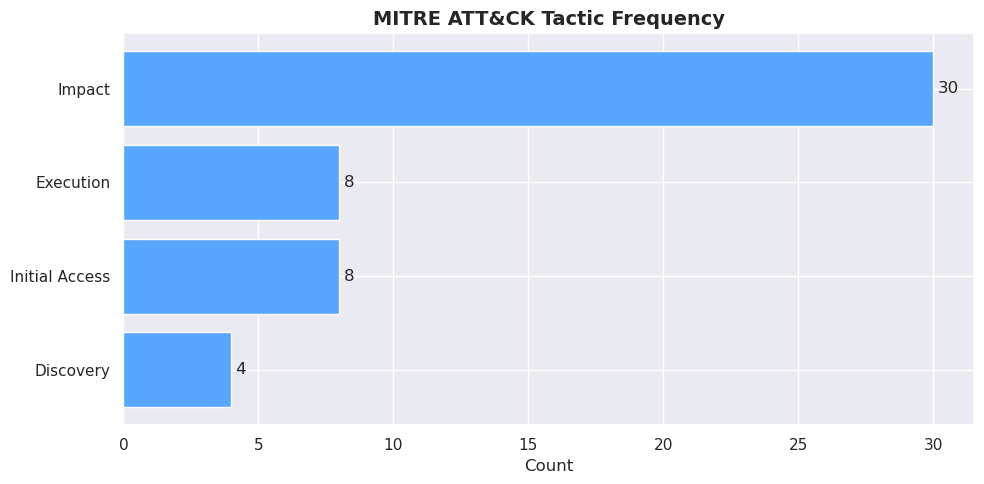

In [4]:
# ── 3. MITRE ATT&CK Tactic Frequency ──────────────────────────────────────
tactic_counts = attacks_df['mitre_tactic'].replace('N/A', 'Unknown').value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(tactic_counts.index, tactic_counts.values, color='#58a6ff', edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('MITRE ATT&CK Tactic Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

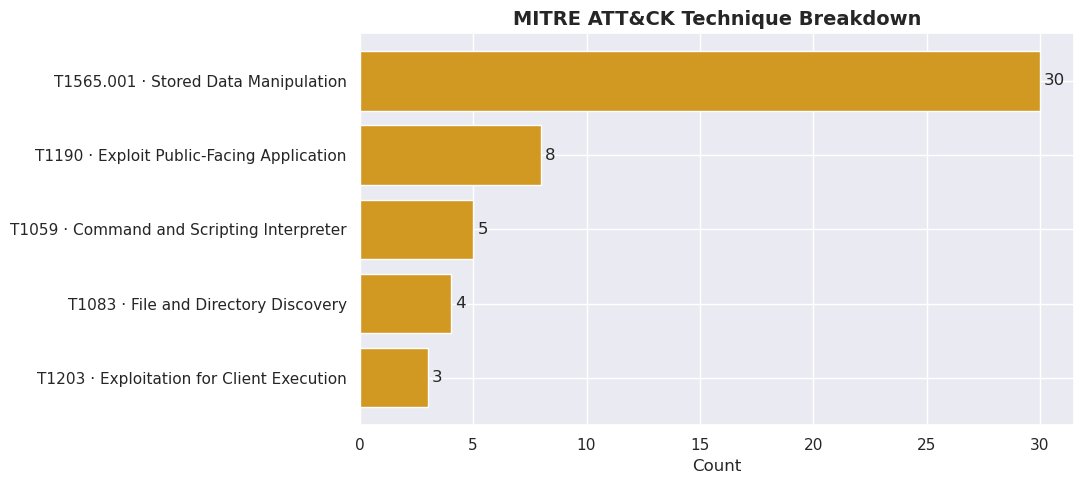

In [5]:
# ── 4. MITRE ATT&CK Technique IDs ─────────────────────────────────────────
tech_counts = attacks_df.groupby(['mitre_id', 'mitre_name']).size().reset_index(name='count')
tech_counts['label'] = tech_counts['mitre_id'] + ' · ' + tech_counts['mitre_name']
tech_counts = tech_counts.sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(tech_counts['label'], tech_counts['count'], color='#d29922', edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('MITRE ATT&CK Technique Breakdown', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

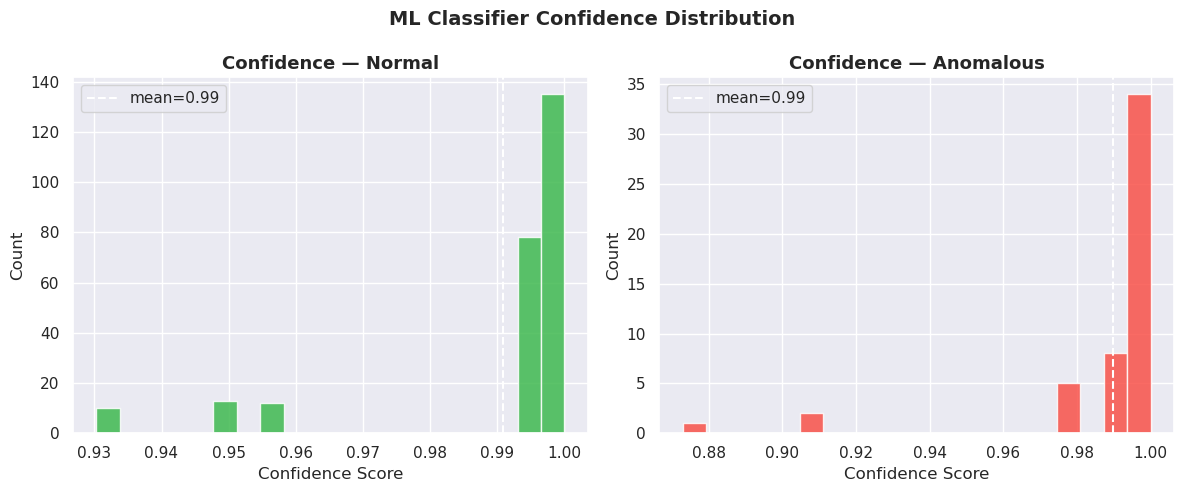

In [6]:
# ── 5. ML Confidence Score Histogram ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, label, color in zip(axes, ['normal', 'anomalous'], ['#3fb950', '#f85149']):
    subset = df[df['ml_label'] == label]['confidence']
    if len(subset) == 0:
        ax.set_title(f'No {label} events')
        continue
    ax.hist(subset, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Confidence — {label.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Confidence Score')
    ax.set_ylabel('Count')
    ax.axvline(subset.mean(), color='white', linestyle='--', label=f'mean={subset.mean():.2f}')
    ax.legend()

plt.suptitle('ML Classifier Confidence Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

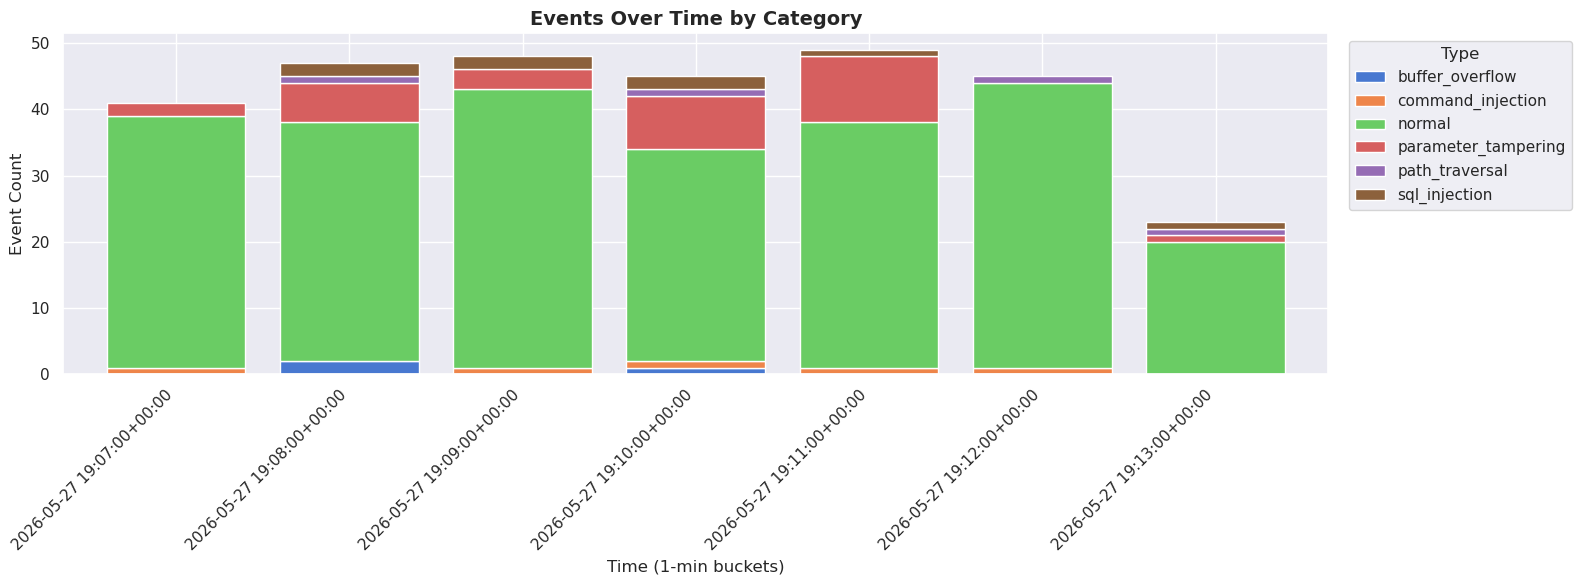

In [7]:
# ── 6. Events Over Time (stacked bar — attack types by time bucket) ────────
df['time_bucket'] = df['timestamp'].dt.floor('1min')
df['display_type'] = df.apply(
    lambda r: r['attack_type'] if r['ml_label'] == 'anomalous' and r['attack_type'] else r['ml_label'],
    axis=1
)

pivot = (
    df.groupby(['time_bucket', 'display_type'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

if len(pivot) > 1:
    fig, ax = plt.subplots(figsize=(16, 6))
    pivot.plot(kind='bar', stacked=True, width=0.8, ax=ax)
    ax.set_title('Events Over Time by Category', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (1-min buckets)')
    ax.set_ylabel('Event Count')
    ax.legend(title='Type', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough time data yet — run producer + consumer for longer and re-run this cell.')

In [8]:
# ── 7. Summary Table ───────────────────────────────────────────────────────
total      = len(df)
n_normal   = (df['ml_label'] == 'normal').sum()
n_attack   = (df['ml_label'] == 'anomalous').sum()
avg_conf   = df['confidence'].mean()
top_attack = attacks_df['attack_type'].replace('','unknown').value_counts().idxmax() if len(attacks_df) > 0 else 'N/A'
top_tactic = attacks_df['mitre_tactic'].value_counts().idxmax() if len(attacks_df) > 0 else 'N/A'

print('=' * 50)
print('        PIPELINE SUMMARY')
print('=' * 50)
print(f'  Total events processed : {total}')
print(f'  Normal requests        : {n_normal} ({n_normal/total*100:.1f}%)')
print(f'  Attack requests        : {n_attack} ({n_attack/total*100:.1f}%)')
print(f'  Avg classifier conf.   : {avg_conf:.1%}')
print(f'  Most common attack     : {top_attack}')
print(f'  Most common tactic     : {top_tactic}')
print('=' * 50)
print('\nAttack type breakdown:')
print(attacks_df['attack_type'].replace('','unknown').value_counts().to_string())
print('\nMITRE tactic breakdown:')
print(attacks_df['mitre_tactic'].value_counts().to_string())

        PIPELINE SUMMARY
  Total events processed : 298
  Normal requests        : 248 (83.2%)
  Attack requests        : 50 (16.8%)
  Avg classifier conf.   : 99.1%
  Most common attack     : parameter_tampering
  Most common tactic     : Impact

Attack type breakdown:
attack_type
parameter_tampering    30
sql_injection           8
command_injection       5
path_traversal          4
buffer_overflow         3

MITRE tactic breakdown:
mitre_tactic
Impact            30
Execution          8
Initial Access     8
Discovery          4


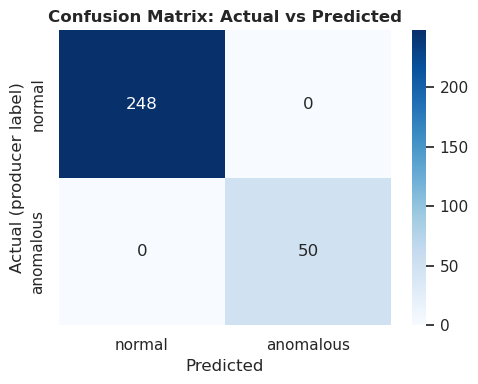

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        50
   anomalous       1.00      1.00      1.00       248

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298

✅ No misclassifications in this batch!


In [9]:
# -- 8. Producer label vs Classifier label (accuracy table) ─────────────────
# The 'label' column is the ground truth sent by the producer.
# The 'ml_label' column is what the ML classifier predicted.
if 'label' not in df.columns or df['label'].eq('').all():
    print('No ground-truth labels in CSV — run notebooks 1 and 2 again.')
else:
    from sklearn.metrics import classification_report, confusion_matrix

    truth = df['label']
    pred  = df['ml_label']

    # Confusion matrix
    cm = confusion_matrix(truth, pred, labels=['normal', 'anomalous'])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['normal', 'anomalous'],
                yticklabels=['normal', 'anomalous'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual (producer label)')
    ax.set_title('Confusion Matrix: Actual vs Predicted', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Classification report
    print(classification_report(truth, pred, target_names=['normal', 'anomalous']))

    # Sample of misclassified requests
    wrong = df[truth != pred][['method', 'url', 'label', 'ml_label', 'confidence']].head(10)
    if len(wrong) == 0:
        print('\u2705 No misclassifications in this batch!')
    else:
        print(f'Misclassified requests ({len(wrong)} shown):')
        print(wrong.to_string(index=False))


In [10]:
# -- 9. Attack Chain Analysis ─────────────────────────────────────────────
if 'chain_detected' not in df.columns or df['chain_detected'].eq('').all():
    print('No chain data yet — run notebooks 1 and 2 with the updated producer.')
else:
    chain_df = df[df['chain_detected'].notna() & (df['chain_detected'] != '')]

    print(f'Total chain alerts    : {len(chain_df)}')
    print(f'Unique attack sessions: {chain_df["chain_detected"].nunique()}')
    print()

    # Count how often each chain pattern appeared
    chain_counts = chain_df['chain_detected'].value_counts()
    print('Chain patterns detected:')
    for pattern, count in chain_counts.items():
        steps = pattern.replace(',', ' -> ')
        print(f'  {count:>3}x  {steps}')

    if len(chain_counts) > 0:
        fig, ax = plt.subplots(figsize=(11, 4))
        labels = [p.replace(',', ' -> ') for p in chain_counts.index]
        bars = ax.barh(labels, chain_counts.values, color='#ff7b72', edgecolor='white')
        ax.bar_label(bars, padding=3)
        ax.set_title('Detected Attack Chain Patterns', fontsize=14, fontweight='bold')
        ax.set_xlabel('Number of events flagged')
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()


Total chain alerts    : 0
Unique attack sessions: 0

Chain patterns detected:
